In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [7]:
# Lorenz system functions

def lorenz_deriv(state, t, sigma, rho, beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]


def generate_lorenz_data(x0=1, y0=1, z0=1, sigma=10, rho=28, beta=8/3, dt=0.01, t_max=100):
    t = np.arange(0, t_max, dt)
    n = len(t)
    x = np.zeros(n)
    y = np.zeros(n)
    z = np.zeros(n)
    x[0], y[0], z[0] = x0, y0, z0
    for i in range(n-1):
        state = [x[i], y[i], z[i]]
        k1 = lorenz_deriv(state, t[i], sigma, rho, beta)
        k2 = lorenz_deriv([x[i] + 0.5*dt*k1[0], y[i] + 0.5*dt*k1[1], z[i] + 0.5*dt*k1[2]], t[i] + 0.5*dt, sigma, rho, beta)
        k3 = lorenz_deriv([x[i] + 0.5*dt*k2[0], y[i] + 0.5*dt*k2[1], z[i] + 0.5*dt*k2[2]], t[i] + 0.5*dt, sigma, rho, beta)
        k4 = lorenz_deriv([x[i] + dt*k3[0], y[i] + dt*k3[1], z[i] + dt*k3[2]], t[i] + dt, sigma, rho, beta)
        x[i+1] = x[i] + (dt/6) * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
        y[i+1] = y[i] + (dt/6) * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
        z[i+1] = z[i] + (dt/6) * (k1[2] + 2*k2[2] + 2*k3[2] + k4[2])
    return t, x, y, z


def plot_lorenz(t, x, y, z):
    fig = plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(t, x)
    plt.title('x vs time')
    plt.subplot(1, 3, 2)
    plt.plot(t, y)
    plt.title('y vs time')
    plt.subplot(1, 3, 3)
    plt.plot(t, z)
    plt.title('z vs time')
    plt.tight_layout()
    plt.show()

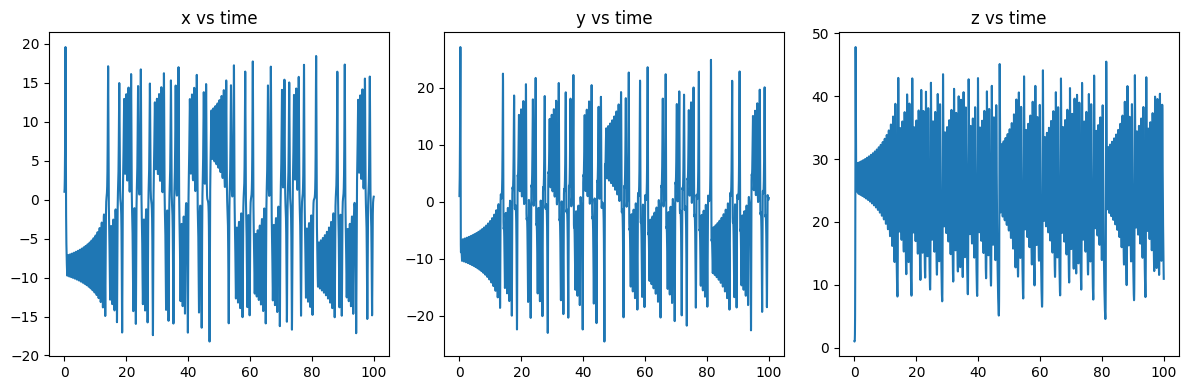

In [8]:
# Generate Lorenz data
t, x, y, z = generate_lorenz_data()

# Plot the data
plot_lorenz(t, x, y, z)

In [9]:
# Reservoir system functions

def W_create(row, col, p, J):
    k = p * row
    strength = J / k
    random_probs = np.random.rand(row, col)
    adjacency = (random_probs < p).astype(float)
    signs = np.random.choice([-1, 1], size=(row, col))
    return adjacency * signs * strength


def Res_step(x, W, Win, u, leak_rate):
    return x * (1 - leak_rate) + leak_rate * np.tanh(W @ x + Win @ u)


def collect_states(W, Win, train_len, washout_len, U):
    r = np.zeros(W.shape[0])
    stored_states = []
    for i in range(train_len):
        u = U[i]
        r = Res_step(r, W, Win, u, leak_rate=0.3)
        if i >= washout_len:
            stored_states.append((r.copy(), U[i + 1].copy()))
    return stored_states


def train_Wout(states, reg=1e-6):
    R = np.vstack([r for r, _ in states])
    U = np.vstack([u for _, u in states])
    return np.linalg.solve(R.T @ R + reg * np.eye(R.shape[1]), R.T @ U).T


def Res_step_self_sustained(r, W, Win, Wout, leak_rate=0.3):
    u_pred = Wout @ r
    r_next = r * (1 - leak_rate) + leak_rate * np.tanh(W @ r + Win @ u_pred)
    return r_next, u_pred


def generate_predictions_whole(W, Win, Wout, U, teacher_len, leak_rate=0.3):
    r = np.zeros(W.shape[0])
    predictions = []
    for i in range(teacher_len):
        r = Res_step(r, W, Win, U[i], leak_rate)
        predictions.append(U[i])
    for _ in range(len(U) - teacher_len):
        r, u_pred = Res_step_self_sustained(r, W, Win, Wout, leak_rate)
        predictions.append(u_pred)
    return np.vstack(predictions)

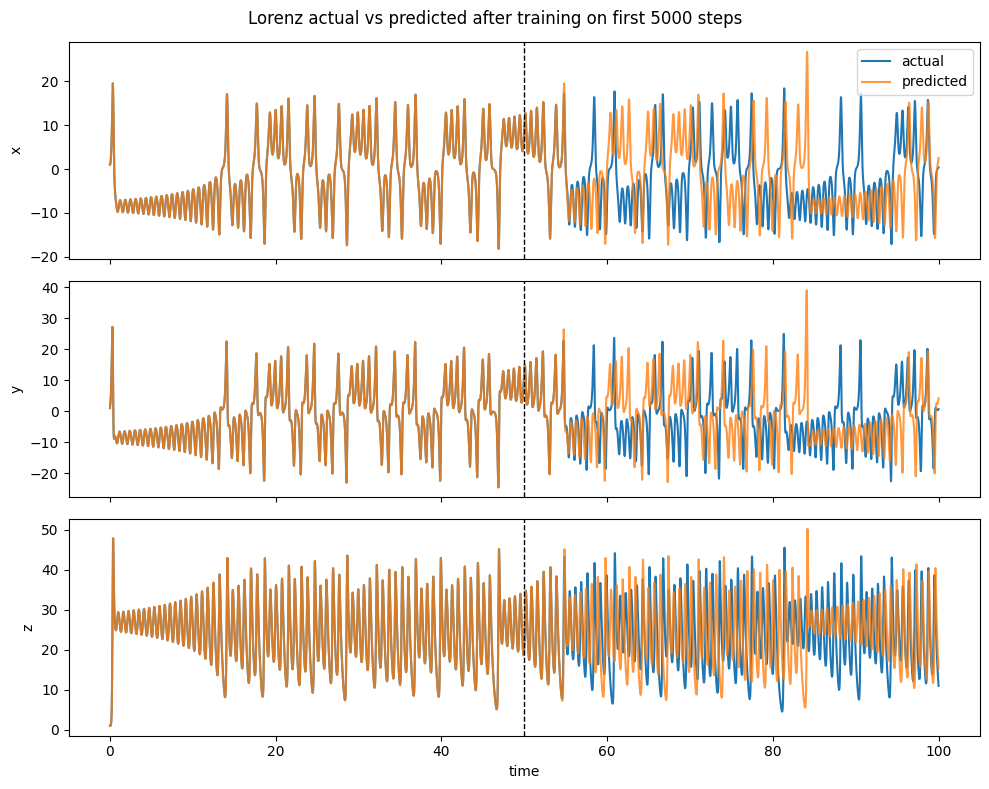

In [10]:
# Parameter setup and plotting

n_reservoir = 300
input_dim = 3
reservoir_density = 0.1
weight_scale = 4
leak_rate = 0.3

dt = 0.01
t_max = 100
train_len = 5000
washout_len = 1000

#creating the W and Win matrices
W = W_create(row=n_reservoir, col=n_reservoir, p=reservoir_density, J=weight_scale)
Win = W_create(row=n_reservoir, col=input_dim, p=0.5, J=weight_scale)

#generate the lorenz time series
t, x, y, z = generate_lorenz_data(dt=dt, t_max=t_max)
U = np.column_stack((x, y, z))

#collect states and train Wout
states = collect_states(W, Win, train_len, washout_len, U)
Wout = train_Wout(states)

#generate predictions and plot results
predicted = generate_predictions_whole(W, Win, Wout, U, train_len, leak_rate=leak_rate)
actual = U
time_pred = t

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = ['x', 'y', 'z']
for j, ax in enumerate(axes):
    ax.plot(time_pred, actual[:, j], label='actual', color='tab:blue')
    ax.plot(time_pred, predicted[:, j], label='predicted', color='tab:orange', alpha=0.8)
    ax.axvline(time_pred[train_len], color='k', linestyle='--', linewidth=1)
    ax.set_ylabel(labels[j])
    if j == 0:
        ax.legend(loc='upper right')
axes[-1].set_xlabel('time')
fig.suptitle('Lorenz actual vs predicted after training on first 5000 steps')
plt.tight_layout()
plt.show()


We use an Erdos Reyni network for W and Win. The real predicitons start after the dashed line at t=50, and continue for a while before diverging but sitll keeping simialr dynamics, which is a known porperty of res computing. 